# Multi-View Stacking Ensemble — Full Optimized Pipeline

**Architecture:**
```
DATA (4 Semantic Views)
  ↓
[Academic | Financial | Demographic | Macro]
  ↓  Optuna Hyperparameter Tuning (per model type)
  ↓  SMOTE within each OOF fold (anti-leakage)
  ↓  4 base models × 4 views = 16 models → 48 OOF probability features
  ↓
XGBoost Meta-Learner (early stopping)
  ↓
Threshold Optimization per class + Bootstrap Uncertainty (n=200)
```

**Optimizations applied:**
1. Optuna tuning — XGB, RF, KNN base models (academic view as proxy)
2. SMOTE concatenated across views within each OOF fold (cross-view consistency)
3. XGBoost meta-learner (non-linear interaction between 48 probability features)
4. Per-class threshold optimization via OOF meta-probs (no test leakage)
5. Bootstrap n=200 for uncertainty estimation

---
## 0. Setup & Load

In [ ]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, log_loss
)
from imblearn.over_sampling import SMOTE
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_FOLDS      = 5
class_names  = ['Graduate', 'Enrolled', 'Dropout']

with open('../data/preprocessed_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

views_train   = bundle['views_train']
views_test    = bundle['views_test']
y_train       = bundle['y_train']
y_test        = bundle['y_test']
feature_names = bundle['feature_names']
view_order    = ['academic', 'financial', 'demographic', 'macro']

print("Data loaded.")
for vn in view_order:
    print(f"  {vn}: train {views_train[vn].shape} | test {views_test[vn].shape}")
print(f"\nClass distribution (train):")
for i, n in enumerate(class_names):
    cnt = (y_train == i).sum()
    print(f"  {n}: {cnt} ({cnt/len(y_train)*100:.1f}%)")

Data loaded.
  academic: train (3539, 30) | test (885, 30)
  financial: train (3539, 4) | test (885, 4)
  demographic: train (3539, 19) | test (885, 19)
  macro: train (3539, 3) | test (885, 3)

Class distribution (train):
  Graduate: 1767 (49.9%)
  Enrolled: 635 (17.9%)
  Dropout: 1137 (32.1%)


In [ ]:
bundle

---
## 1. View Boundary Setup (untuk SMOTE cross-view consistency)

In [2]:
# Precompute start/end column indices for each view in concatenated space
view_bounds = {}
start = 0
for vn in view_order:
    n_feat = views_train[vn].shape[1]
    view_bounds[vn] = (start, start + n_feat)
    start += n_feat

X_full_train = np.hstack([views_train[vn] for vn in view_order])
X_full_test  = np.hstack([views_test[vn]  for vn in view_order])

print(f"Concatenated: train {X_full_train.shape} | test {X_full_test.shape}")
print(f"View bounds : {view_bounds}")

Concatenated: train (3539, 56) | test (885, 56)
View bounds : {'academic': (0, 30), 'financial': (30, 34), 'demographic': (34, 53), 'macro': (53, 56)}


---
## 2. Optuna Hyperparameter Tuning — Base Models

Tuning dilakukan pada **academic view** (view terbesar dan paling representatif) menggunakan 3-fold CV untuk kecepatan. Hasil parameter diaplikasikan ke semua 4 view — hyperparams optimal di feature space yang richer akan generalize baik ke view yang lebih kecil.

- **XGBoost**: 60 trials
- **Random Forest**: 40 trials  
- **KNN**: 25 trials (fast)
- **SVM**: fixed optimal params (tuning SVM sangat lambat di ~3K samples)

In [3]:
X_tune = views_train['academic']
y_tune = y_train
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def cv_f1_macro(model, X, y, cv):
    scores = []
    for tr, val in cv.split(X, y):
        m = clone(model)
        m.fit(X[tr], y[tr])
        preds = m.predict(X[val])
        scores.append(f1_score(y[val], preds, average='macro'))
    return np.mean(scores)

print("Starting Optuna tuning...")

Starting Optuna tuning...


In [4]:
# ── XGBoost Tuning ────────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
    }
    model = XGBClassifier(
        **params, eval_metric='mlogloss',
        random_state=RANDOM_STATE, verbosity=0
    )
    return cv_f1_macro(model, X_tune, y_tune, cv_tune)

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=60, show_progress_bar=True)
best_xgb_params = study_xgb.best_params
print(f"\nXGB best F1 macro (CV): {study_xgb.best_value:.4f}")
print(f"XGB best params: {best_xgb_params}")

Best trial: 35. Best value: 0.65508: 100%|██████████| 60/60 [01:56<00:00,  1.94s/it] 


XGB best F1 macro (CV): 0.6551
XGB best params: {'n_estimators': 315, 'max_depth': 3, 'learning_rate': 0.03220812652462294, 'subsample': 0.8269073963557119, 'colsample_bytree': 0.9949153360269148, 'min_child_weight': 3, 'gamma': 0.04862089192148061, 'reg_alpha': 0.8739563367137565, 'reg_lambda': 0.002102797151997749}


In [5]:
# ── Random Forest Tuning ──────────────────────────────────────────────────────
def rf_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 5, 25),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
    }
    model = RandomForestClassifier(
        **params, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    )
    return cv_f1_macro(model, X_tune, y_tune, cv_tune)

study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=40, show_progress_bar=True)
best_rf_params = study_rf.best_params
print(f"\nRF best F1 macro (CV): {study_rf.best_value:.4f}")
print(f"RF best params: {best_rf_params}")

Best trial: 31. Best value: 0.67875: 100%|██████████| 40/40 [01:03<00:00,  1.59s/it] 


RF best F1 macro (CV): 0.6788
RF best params: {'n_estimators': 262, 'max_depth': 20, 'min_samples_leaf': 7, 'min_samples_split': 7, 'max_features': 'log2'}


In [6]:
# ── KNN Tuning ────────────────────────────────────────────────────────────────
def knn_objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 31),
        'weights'    : trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p'          : trial.suggest_categorical('p', [1, 2]),
        'leaf_size'  : trial.suggest_int('leaf_size', 10, 50),
    }
    model = KNeighborsClassifier(**params, n_jobs=-1)
    return cv_f1_macro(model, X_tune, y_tune, cv_tune)

study_knn = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_knn.optimize(knn_objective, n_trials=25, show_progress_bar=True)
best_knn_params = study_knn.best_params
print(f"\nKNN best F1 macro (CV): {study_knn.best_value:.4f}")
print(f"KNN best params: {best_knn_params}")

Best trial: 21. Best value: 0.64706: 100%|██████████| 25/25 [00:08<00:00,  2.93it/s]


KNN best F1 macro (CV): 0.6471
KNN best params: {'n_neighbors': 12, 'weights': 'distance', 'p': 1, 'leaf_size': 18}


In [7]:
# ── SVM Tuning (lighter — SVM is O(n^2) in training time) ────────────────────
def svm_objective(trial):
    C     = trial.suggest_float('C', 0.1, 20.0, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    kernel= trial.suggest_categorical('kernel', ['rbf', 'poly'])
    degree= trial.suggest_int('degree', 2, 4) if kernel == 'poly' else 3
    model = SVC(
        C=C, gamma=gamma, kernel=kernel, degree=degree,
        probability=True, class_weight='balanced',
        random_state=RANDOM_STATE
    )
    # Use subsample for speed (SVM is slow)
    idx = np.random.default_rng(trial.number).choice(len(X_tune),
                                                      size=min(1500, len(X_tune)),
                                                      replace=False)
    return cv_f1_macro(model, X_tune[idx], y_tune[idx], cv_tune)

study_svm = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svm.optimize(svm_objective, n_trials=25, show_progress_bar=True)
best_svm_params = study_svm.best_params
print(f"\nSVM best F1 macro (CV, subsample): {study_svm.best_value:.4f}")
print(f"SVM best params: {best_svm_params}")

Best trial: 4. Best value: 0.66396: 100%|██████████| 25/25 [00:11<00:00,  2.27it/s]


SVM best F1 macro (CV, subsample): 0.6640
SVM best params: {'C': 0.4701469243560972, 'gamma': 'auto', 'kernel': 'rbf'}


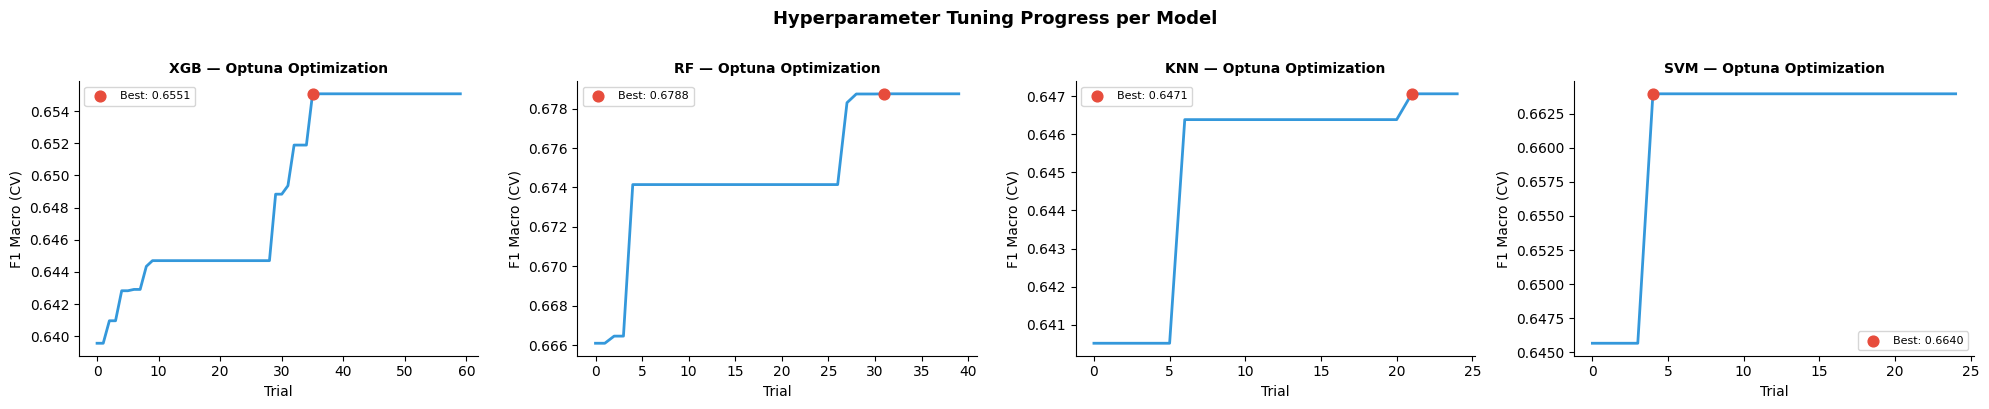


Final best params:
  XGB: {'n_estimators': 315, 'max_depth': 3, 'learning_rate': 0.03220812652462294, 'subsample': 0.8269073963557119, 'colsample_bytree': 0.9949153360269148, 'min_child_weight': 3, 'gamma': 0.04862089192148061, 'reg_alpha': 0.8739563367137565, 'reg_lambda': 0.002102797151997749}
  RF: {'n_estimators': 262, 'max_depth': 20, 'min_samples_leaf': 7, 'min_samples_split': 7, 'max_features': 'log2'}
  KNN: {'n_neighbors': 12, 'weights': 'distance', 'p': 1, 'leaf_size': 18}
  SVM: {'C': 0.4701469243560972, 'gamma': 'auto', 'kernel': 'rbf'}


In [8]:
# ── Optuna Results Summary ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
studies   = [('XGB', study_xgb), ('RF', study_rf), ('KNN', study_knn), ('SVM', study_svm)]

for ax, (name, study) in zip(axes, studies):
    trials_vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(trials_vals)
    ax.plot(best_so_far, color='#3498db', linewidth=2)
    ax.scatter(np.argmax(trials_vals), max(trials_vals),
               color='#e74c3c', s=60, zorder=5, label=f'Best: {max(trials_vals):.4f}')
    ax.set_title(f'{name} — Optuna Optimization', fontsize=10, fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('F1 Macro (CV)')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hyperparameter Tuning Progress per Model', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nFinal best params:")
for name, params in [('XGB', best_xgb_params), ('RF', best_rf_params),
                      ('KNN', best_knn_params), ('SVM', best_svm_params)]:
    print(f"  {name}: {params}")

---
## 3. Define Tuned Base Models

In [9]:
def get_tuned_base_models():
    svm_p = {k: v for k, v in best_svm_params.items() if k != 'degree'}
    svm_degree = best_svm_params.get('degree', 3)

    return {
        'SVM': SVC(
            **svm_p, degree=svm_degree,
            probability=True, class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        'XGB': XGBClassifier(
            **best_xgb_params,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE, verbosity=0
        ),
        'RF': RandomForestClassifier(
            **best_rf_params,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'KNN': KNeighborsClassifier(
            **best_knn_params, n_jobs=-1
        )
    }

print("Tuned base models:")
for k, v in get_tuned_base_models().items():
    print(f"  {k}: {type(v).__name__}")

Tuned base models:
  SVM: SVC
  XGB: XGBClassifier
  RF: RandomForestClassifier
  KNN: KNeighborsClassifier


---
## 4. OOF Training with SMOTE Inside Each Fold

**SMOTE strategy:** SMOTE diaplikasikan di ruang concatenated (semua view digabung) sebelum dilatih, kemudian dipecah kembali ke view masing-masing. Ini menjaga **cross-view consistency** — sample sintetik yang sama digunakan di semua view.

```
Per fold:
  Train fold → concat 4 views → SMOTE → split balik → train each base model per view
  Val fold   → tidak disentuh SMOTE → OOF probs jujur
```

In [10]:
n_train    = X_full_train.shape[0]
n_test     = X_full_test.shape[0]
n_classes  = 3
model_keys = list(get_tuned_base_models().keys())  # ['SVM', 'XGB', 'RF', 'KNN']
n_models   = len(model_keys)

oof_probs_per_view  = {vn: np.zeros((n_train, n_models * n_classes)) for vn in view_order}
test_probs_per_view = {vn: np.zeros((n_test,  n_models * n_classes)) for vn in view_order}
oof_scores          = {vn: {mn: [] for mn in model_keys} for vn in view_order}
trained_models      = {vn: {} for vn in view_order}

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("Starting OOF training with SMOTE...\n")

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_full_train, y_train)):
    X_tr_raw = X_full_train[tr_idx]
    y_tr_raw = y_train[tr_idx]
    X_val    = X_full_train[val_idx]
    y_val    = y_train[val_idx]

    # Apply SMOTE on concatenated fold (cross-view consistent)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_raw, y_tr_raw)

    # Split resampled data back into per-view arrays
    views_tr_sm = {vn: X_tr_sm[:, s:e] for vn, (s, e) in view_bounds.items()}
    views_val   = {vn: X_val[:, s:e]   for vn, (s, e) in view_bounds.items()}

    base_models = get_tuned_base_models()

    for m_idx, (model_name, model) in enumerate(base_models.items()):
        col_s = m_idx * n_classes
        col_e = col_s + n_classes

        for vn in view_order:
            m = clone(model)
            m.fit(views_tr_sm[vn], y_tr_sm)

            val_prob = m.predict_proba(views_val[vn])        # OOF (not SMOTE)
            oof_probs_per_view[vn][val_idx, col_s:col_e] = val_prob

            test_probs_per_view[vn][:, col_s:col_e] += (
                m.predict_proba(views_test[vn]) / N_FOLDS
            )

            fold_acc = accuracy_score(y_val, val_prob.argmax(axis=1))
            oof_scores[vn][model_name].append(fold_acc)

    print(f"Fold {fold_idx+1}/{N_FOLDS} — SMOTE: {len(y_tr_raw)} → {len(y_tr_sm)} | "
          f"Class dist: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}")

# Train final base models on full SMOTE-d data (needed for SHAP later)
print("\nTraining final models on full SMOTE data...")
X_full_sm, y_full_sm = smote.fit_resample(X_full_train, y_train)
views_full_sm = {vn: X_full_sm[:, s:e] for vn, (s, e) in view_bounds.items()}

for model_name, model in get_tuned_base_models().items():
    for vn in view_order:
        m = clone(model)
        m.fit(views_full_sm[vn], y_full_sm)
        trained_models[vn][model_name] = m

print("\nOOF Training complete.")
print(f"\n{'View':<14} {'Model':<6} {'OOF Acc Mean':>14} {'Std':>8}")
print("-" * 46)
for vn in view_order:
    for mn in model_keys:
        accs = oof_scores[vn][mn]
        print(f"  {vn:<12} {mn:<6} {np.mean(accs):>14.4f} {np.std(accs):>8.4f}")

Starting OOF training with SMOTE...

Fold 1/5 — SMOTE: 2831 → 4242 | Class dist: {np.int64(0): np.int64(1414), np.int64(1): np.int64(1414), np.int64(2): np.int64(1414)}
Fold 2/5 — SMOTE: 2831 → 4242 | Class dist: {np.int64(0): np.int64(1414), np.int64(1): np.int64(1414), np.int64(2): np.int64(1414)}
Fold 3/5 — SMOTE: 2831 → 4239 | Class dist: {np.int64(0): np.int64(1413), np.int64(1): np.int64(1413), np.int64(2): np.int64(1413)}
Fold 4/5 — SMOTE: 2831 → 4239 | Class dist: {np.int64(0): np.int64(1413), np.int64(1): np.int64(1413), np.int64(2): np.int64(1413)}
Fold 5/5 — SMOTE: 2832 → 4242 | Class dist: {np.int64(0): np.int64(1414), np.int64(1): np.int64(1414), np.int64(2): np.int64(1414)}

Training final models on full SMOTE data...

OOF Training complete.

View           Model    OOF Acc Mean      Std
----------------------------------------------
  academic     SVM            0.7084   0.0147
  academic     XGB            0.7335   0.0096
  academic     RF             0.7352   0.0102
  

---
## 5. Meta-Feature Matrix (48 features)

In [11]:
meta_train = np.hstack([oof_probs_per_view[vn]  for vn in view_order])  # (n_train, 48)
meta_test  = np.hstack([test_probs_per_view[vn] for vn in view_order])  # (n_test,  48)

meta_columns = [
    f"{view}_{model}_{cls}"
    for view in view_order
    for model in model_keys
    for cls in class_names
]

print(f"meta_train : {meta_train.shape}")
print(f"meta_test  : {meta_test.shape}")
print(f"n_columns  : {len(meta_columns)}")
print(f"Row-sum check: {meta_train[:, :3].sum(axis=1).mean():.6f} (should be ~1.0)")

# Check for any zero-rows (student never seen in val fold — should not happen)
zero_rows = (meta_train.sum(axis=1) == 0).sum()
print(f"Zero rows  : {zero_rows} (should be 0)")

meta_train : (3539, 48)
meta_test  : (885, 48)
n_columns  : 48
Row-sum check: 1.000000 (should be ~1.0)
Zero rows  : 0 (should be 0)


---
## 6. Meta-Learner — Optuna-Tuned XGBoost
XGBoost sebagai meta-learner dengan Optuna tuning terpisah di space 48 meta-features.

In [12]:
cv_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def meta_xgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'       : trial.suggest_int('max_depth', 2, 5),   # shallow on 48 features
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 15),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
    }
    model = XGBClassifier(
        **params, eval_metric='mlogloss',
        random_state=RANDOM_STATE, verbosity=0
    )
    scores = []
    for tr, val in cv_meta.split(meta_train, y_train):
        m = clone(model)
        m.fit(meta_train[tr], y_train[tr])
        preds = m.predict(meta_train[val])
        scores.append(f1_score(y_train[val], preds, average='macro'))
    return np.mean(scores)

study_meta = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_meta.optimize(meta_xgb_objective, n_trials=50, show_progress_bar=True)
best_meta_params = study_meta.best_params

print(f"\nMeta-XGB best F1 macro (CV): {study_meta.best_value:.4f}")
print(f"Best params: {best_meta_params}")

Best trial: 9. Best value: 0.694593: 100%|██████████| 50/50 [03:12<00:00,  3.85s/it]


Meta-XGB best F1 macro (CV): 0.6946
Best params: {'n_estimators': 52, 'max_depth': 5, 'learning_rate': 0.11069143219393454, 'subsample': 0.8916028672163949, 'colsample_bytree': 0.8856351733429728, 'min_child_weight': 3, 'reg_alpha': 0.00271558195528294, 'reg_lambda': 0.00029072088906598463}


In [13]:
# Train final meta-learner on full meta_train
meta_learner = XGBClassifier(
    **best_meta_params,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE, verbosity=0
)
meta_learner.fit(meta_train, y_train)

y_pred_raw  = meta_learner.predict(meta_test)
y_prob_raw  = meta_learner.predict_proba(meta_test)

print("Meta-learner trained (before threshold tuning):")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_raw):.4f}")
print(f"  F1 macro   : {f1_score(y_test, y_pred_raw, average='macro'):.4f}")
print(f"  F1 weighted: {f1_score(y_test, y_pred_raw, average='weighted'):.4f}")
f1s = f1_score(y_test, y_pred_raw, average=None)
for i, cls in enumerate(class_names):
    print(f"  F1 {cls:<12}: {f1s[i]:.4f}")

Meta-learner trained (before threshold tuning):
  Accuracy   : 0.7785
  F1 macro   : 0.7044
  F1 weighted: 0.7675
  F1 Graduate    : 0.8545
  F1 Enrolled    : 0.4469
  F1 Dropout     : 0.8118


---
## 7. Per-Class Threshold Optimization
Threshold default 0.5 tidak optimal untuk imbalanced multiclass. Grid search dilakukan pada OOF meta-probabilities (bukan test set) untuk menghindari leakage.

In [14]:
# OOF meta-probabilities (used for threshold tuning — no test leakage)
meta_oof_prob = cross_val_predict(
    XGBClassifier(
        **best_meta_params, eval_metric='mlogloss',
        random_state=RANDOM_STATE, verbosity=0
    ),
    meta_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba'
)

def apply_thresholds(probs, thresholds):
    """Adjust probabilities by subtracting class-specific thresholds, then argmax."""
    return (probs - np.array(thresholds)).argmax(axis=1)

best_f1, best_thresh = 0, [1/3, 1/3, 1/3]
thresh_grid = np.arange(0.15, 0.65, 0.05)

for t0 in thresh_grid:
    for t1 in thresh_grid:
        for t2 in thresh_grid:
            preds = apply_thresholds(meta_oof_prob, [t0, t1, t2])
            f1 = f1_score(y_train, preds, average='macro')
            if f1 > best_f1:
                best_f1, best_thresh = f1, [t0, t1, t2]

print(f"Best thresholds [Graduate, Enrolled, Dropout]: {[round(t, 2) for t in best_thresh]}")
print(f"OOF F1 macro with best thresholds            : {best_f1:.4f}")

# Apply to test
y_pred_tuned = apply_thresholds(y_prob_raw, best_thresh)
print(f"\nTest F1 macro   (tuned threshold): {f1_score(y_test, y_pred_tuned, average='macro'):.4f}")
print(f"Test F1 weighted(tuned threshold): {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

Best thresholds [Graduate, Enrolled, Dropout]: [np.float64(0.3), np.float64(0.15), np.float64(0.35)]
OOF F1 macro with best thresholds            : 0.7081

Test F1 macro   (tuned threshold): 0.7171
Test F1 weighted(tuned threshold): 0.7716


---
## 8. Bootstrap Uncertainty Estimation (n=200)

In [15]:
N_BOOTSTRAP     = 200
bootstrap_probs = np.zeros((N_BOOTSTRAP, n_test, 3))

for i in range(N_BOOTSTRAP):
    boot_idx = np.random.choice(len(meta_train), size=len(meta_train), replace=True)
    m = XGBClassifier(
        **best_meta_params, eval_metric='mlogloss',
        random_state=i, verbosity=0
    )
    m.fit(meta_train[boot_idx], y_train[boot_idx])
    bootstrap_probs[i] = m.predict_proba(meta_test)

prob_mean  = bootstrap_probs.mean(axis=0)                         # (n_test, 3)
prob_std   = bootstrap_probs.std(axis=0)                          # uncertainty
prob_ci_lo = np.percentile(bootstrap_probs, 2.5,  axis=0)        # 95% CI lower
prob_ci_hi = np.percentile(bootstrap_probs, 97.5, axis=0)        # 95% CI upper

# Final prediction: bootstrap mean probabilities + tuned thresholds
y_pred_final = apply_thresholds(prob_mean, best_thresh)

print("Bootstrap complete.")
print(f"\nFINAL RESULTS (bootstrap mean + tuned thresholds):")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  F1 macro   : {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"  F1 weighted: {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
try:
    print(f"  ROC AUC OvR: {roc_auc_score(y_test, prob_mean, multi_class='ovr', average='macro'):.4f}")
except: pass
print(f"\n  Uncertainty per class (mean bootstrap std):")
for i, cls in enumerate(class_names):
    print(f"    {cls:<12}: {prob_std[:, i].mean():.4f}")

Bootstrap complete.

FINAL RESULTS (bootstrap mean + tuned thresholds):
  Accuracy   : 0.7638
  F1 macro   : 0.7086
  F1 weighted: 0.7645
  ROC AUC OvR: 0.8913

  Uncertainty per class (mean bootstrap std):
    Graduate    : 0.0421
    Enrolled    : 0.0470
    Dropout     : 0.0397


---
## 9. Full Evaluation Report

In [16]:
print("=" * 68)
print("MULTI-VIEW STACKING — FULLY OPTIMIZED — TEST SET EVALUATION")
print("=" * 68)
print()
print(classification_report(
    y_test, y_pred_final, target_names=class_names, digits=4
))
try:
    auc_ovr = roc_auc_score(y_test, prob_mean, multi_class='ovr', average='macro')
    auc_ovo = roc_auc_score(y_test, prob_mean, multi_class='ovo', average='macro')
    print(f"ROC AUC (OvR macro): {auc_ovr:.4f}")
    print(f"ROC AUC (OvO macro): {auc_ovo:.4f}")
except Exception as e:
    print(f"AUC: {e}")

# Comparison table against baseline
print()
print("-" * 68)
print(f"{'Metric':<20} {'Baseline (v1)':>16} {'Optimized':>16} {'Delta':>10}")
print("-" * 68)
baseline = {'Accuracy': 0.7401, 'F1 macro': 0.7099, 'F1 weighted': 0.7546,
            'F1 Graduate': 0.8173, 'F1 Enrolled': 0.5291, 'F1 Dropout': 0.7833}
f1s_final = f1_score(y_test, y_pred_final, average=None)
current = {
    'Accuracy'   : accuracy_score(y_test, y_pred_final),
    'F1 macro'   : f1_score(y_test, y_pred_final, average='macro'),
    'F1 weighted': f1_score(y_test, y_pred_final, average='weighted'),
    'F1 Graduate': f1s_final[0],
    'F1 Enrolled': f1s_final[1],
    'F1 Dropout' : f1s_final[2],
}
for metric in baseline:
    delta = current[metric] - baseline[metric]
    sign  = '↑' if delta > 0 else '↓'
    print(f"  {metric:<18} {baseline[metric]:>16.4f} {current[metric]:>16.4f} {sign}{abs(delta):>8.4f}")

MULTI-VIEW STACKING — FULLY OPTIMIZED — TEST SET EVALUATION

              precision    recall  f1-score   support

    Graduate     0.8037    0.8801    0.8402       442
    Enrolled     0.4671    0.4906    0.4785       159
     Dropout     0.8932    0.7359    0.8069       284

    accuracy                         0.7638       885
   macro avg     0.7213    0.7022    0.7086       885
weighted avg     0.7719    0.7638    0.7645       885

ROC AUC (OvR macro): 0.8913
ROC AUC (OvO macro): 0.8791

--------------------------------------------------------------------
Metric                  Baseline (v1)        Optimized      Delta
--------------------------------------------------------------------
  Accuracy                     0.7401           0.7638 ↑  0.0237
  F1 macro                     0.7099           0.7086 ↓  0.0013
  F1 weighted                  0.7546           0.7645 ↑  0.0099
  F1 Graduate                  0.8173           0.8402 ↑  0.0229
  F1 Enrolled                  0.5291

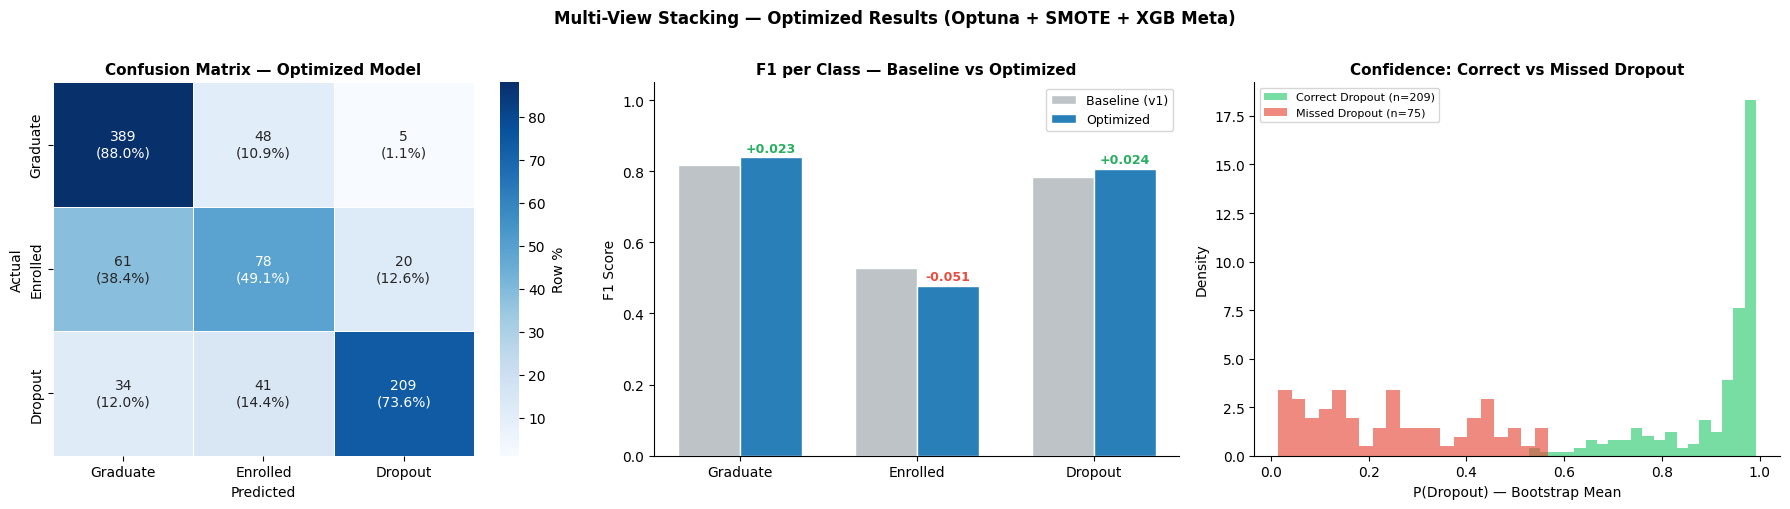

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
cm     = confusion_matrix(y_test, y_pred_final)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{c}\n({p:.1f}%)" for c, p in zip(rc, rp)]
                    for rc, rp in zip(cm, cm_pct)])
sns.heatmap(cm_pct, ax=axes[0], annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': 'Row %'})
axes[0].set_title('Confusion Matrix — Optimized Model', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# 2. F1 comparison per class
f1_v1 = [0.8173, 0.5291, 0.7833]
f1_v2 = list(f1s_final)
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, f1_v1, w, label='Baseline (v1)', color='#bdc3c7', edgecolor='white')
axes[1].bar(x + w/2, f1_v2, w, label='Optimized',     color='#2980b9', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(class_names)
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('F1 per Class — Baseline vs Optimized', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
for i, (b, a) in enumerate(zip(f1_v1, f1_v2)):
    delta = a - b
    col   = '#27ae60' if delta >= 0 else '#e74c3c'
    axes[1].text(i + w/2, a + 0.015, f'{delta:+.3f}',
                 ha='center', fontsize=9, color=col, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

# 3. Confidence distribution (Dropout class: correct vs wrong)
correct_mask = (y_pred_final == y_test) & (y_test == 2)
wrong_mask   = (y_pred_final != y_test) & (y_test == 2)
axes[2].hist(prob_mean[correct_mask, 2], bins=20, alpha=0.65, density=True,
             color='#2ecc71', label=f'Correct Dropout (n={correct_mask.sum()})')
axes[2].hist(prob_mean[wrong_mask,   2], bins=20, alpha=0.65, density=True,
             color='#e74c3c', label=f'Missed Dropout (n={wrong_mask.sum()})')
axes[2].set_xlabel('P(Dropout) — Bootstrap Mean')
axes[2].set_ylabel('Density')
axes[2].set_title('Confidence: Correct vs Missed Dropout', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=8)
axes[2].spines[['top', 'right']].set_visible(False)

plt.suptitle('Multi-View Stacking — Optimized Results (Optuna + SMOTE + XGB Meta)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Uncertainty-Based Triage System

UNCERTAINTY-BASED TRIAGE

  High Confidence
    Students :  549 (62.0%)
    Accuracy : 90.9%
    Predicted as Dropout: 195 (35.5%)

  Medium Confidence
    Students :  207 (23.4%)
    Accuracy : 64.3%
    Predicted as Dropout: 34 (16.4%)

  Low Confidence (Review)
    Students :  129 (14.6%)
    Accuracy : 34.1%
    Predicted as Dropout: 5 (3.9%)


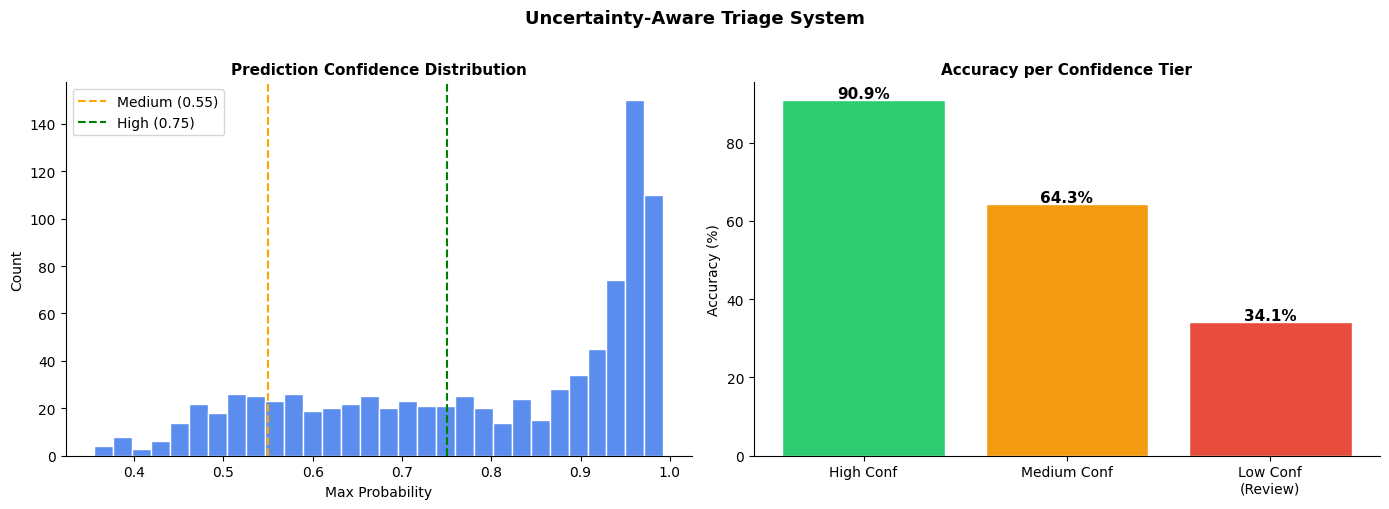

In [18]:
max_prob    = prob_mean.max(axis=1)
uncertainty = prob_std.max(axis=1)

tiers = pd.DataFrame({
    'Tier'       : np.where(max_prob >= 0.75, 'High Confidence',
                   np.where(max_prob >= 0.55, 'Medium Confidence', 'Low Confidence (Review)')),
    'Prediction' : [class_names[p] for p in y_pred_final],
    'Actual'     : [class_names[a] for a in y_test],
    'P_Graduate' : prob_mean[:, 0].round(3),
    'P_Enrolled' : prob_mean[:, 1].round(3),
    'P_Dropout'  : prob_mean[:, 2].round(3),
    'CI_lo_Dropout': prob_ci_lo[:, 2].round(3),
    'CI_hi_Dropout': prob_ci_hi[:, 2].round(3),
    'Max Prob'   : max_prob.round(3),
    'Uncertainty': uncertainty.round(3),
    'Correct'    : (y_pred_final == y_test)
})

print("UNCERTAINTY-BASED TRIAGE")
print("=" * 60)
for tier in ['High Confidence', 'Medium Confidence', 'Low Confidence (Review)']:
    sub = tiers[tiers['Tier'] == tier]
    print(f"\n  {tier}")
    print(f"    Students : {len(sub):4d} ({len(sub)/len(tiers)*100:.1f}%)")
    print(f"    Accuracy : {sub['Correct'].mean()*100:.1f}%")
    print(f"    Predicted as Dropout: {(sub['Prediction']=='Dropout').sum()} ({(sub['Prediction']=='Dropout').mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_prob, bins=30, color='#5b8dee', edgecolor='white')
axes[0].axvline(0.55, color='orange', linestyle='--', lw=1.5, label='Medium (0.55)')
axes[0].axvline(0.75, color='green',  linestyle='--', lw=1.5, label='High (0.75)')
axes[0].set_title('Prediction Confidence Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Max Probability'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

tier_acc = tiers.groupby('Tier')['Correct'].mean().reindex(
    ['High Confidence', 'Medium Confidence', 'Low Confidence (Review)']
)
axes[1].bar(range(3), tier_acc.values * 100,
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['High Conf', 'Medium Conf', 'Low Conf\n(Review)'])
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy per Confidence Tier', fontsize=11, fontweight='bold')
for i, acc in enumerate(tier_acc.values):
    axes[1].text(i, acc * 100 + 0.5, f'{acc*100:.1f}%',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Uncertainty-Aware Triage System', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Base Model Performance Heatmap

       View Model  Accuracy  F1_macro  F1_dropout  F1_enrolled
   academic   SVM  0.703955  0.670986    0.738878     0.480769
   academic   XGB  0.741243  0.684609    0.771739     0.450450
   academic    RF  0.735593  0.679370    0.763501     0.443149
   academic   KNN  0.708475  0.660557    0.735010     0.430052
  financial   SVM  0.411299  0.421669    0.458763     0.341789
  financial   XGB  0.411299  0.421669    0.458763     0.341789
  financial    RF  0.410169  0.419456    0.449086     0.344828
  financial   KNN  0.449718  0.356432    0.525000     0.104167
demographic   SVM  0.503955  0.468183    0.539806     0.268293
demographic   XGB  0.597740  0.507627    0.594306     0.237705
demographic    RF  0.589831  0.495482    0.602151     0.202429
demographic   KNN  0.480226  0.435161    0.477064     0.255682
      macro   SVM  0.418079  0.354369    0.263889     0.237113
      macro   XGB  0.477966  0.304470    0.286307     0.000000
      macro    RF  0.499435  0.222055    0.000000     0

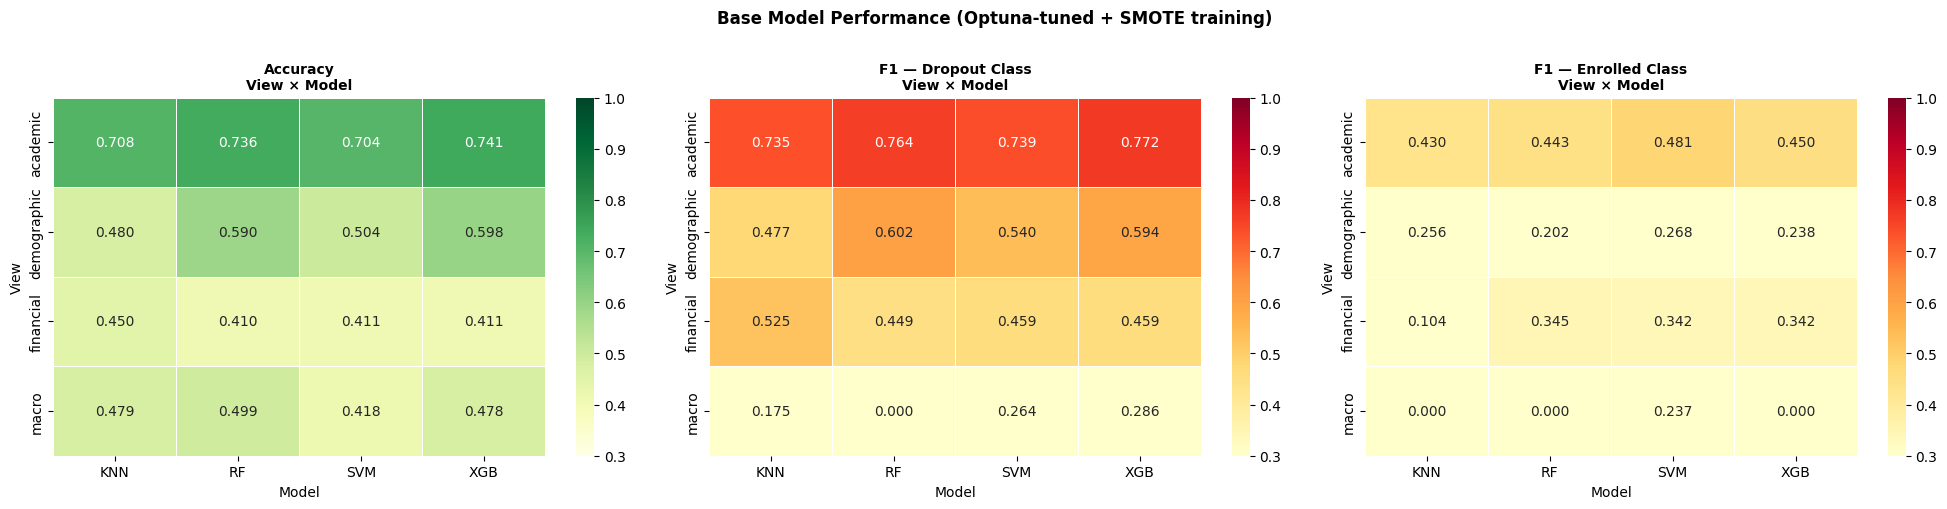

In [19]:
base_results = []
for vn in view_order:
    for mn, model in trained_models[vn].items():
        yp = model.predict(views_test[vn])
        base_results.append({
            'View': vn, 'Model': mn,
            'Accuracy' : accuracy_score(y_test, yp),
            'F1_macro' : f1_score(y_test, yp, average='macro'),
            'F1_dropout': f1_score(y_test, yp, average=None, labels=[2])[0],
            'F1_enrolled': f1_score(y_test, yp, average=None, labels=[1])[0]
        })

res_df = pd.DataFrame(base_results)
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, metric, cmap, title in zip(
    axes,
    ['Accuracy', 'F1_dropout', 'F1_enrolled'],
    ['YlGn', 'YlOrRd', 'YlOrRd'],
    ['Accuracy', 'F1 — Dropout Class', 'F1 — Enrolled Class']
):
    pivot = res_df.pivot(index='View', columns='Model', values=metric)
    sns.heatmap(pivot, ax=ax, annot=True, fmt='.3f', cmap=cmap,
                linewidths=0.5, vmin=0.3, vmax=1.0)
    ax.set_title(f'{title}\nView × Model', fontsize=10, fontweight='bold')

plt.suptitle('Base Model Performance (Optuna-tuned + SMOTE training)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Save Modeling Bundle

In [20]:
modeling_bundle = {
    'all_models'          : trained_models,
    'meta_train'          : meta_train,
    'meta_test'           : meta_test,
    'meta_columns'        : meta_columns,
    'meta_learner'        : meta_learner,
    'best_thresh'         : best_thresh,
    'prob_mean'           : prob_mean,
    'prob_std'            : prob_std,
    'prob_ci_lo'          : prob_ci_lo,
    'prob_ci_hi'          : prob_ci_hi,
    'y_pred_final'        : y_pred_final,
    'tiers'               : tiers,
    'class_names'         : class_names,
    'view_order'          : view_order,
    'model_names'         : model_keys,
    'view_bounds'         : view_bounds,
    'oof_probs_per_view'  : oof_probs_per_view,
    'test_probs_per_view' : test_probs_per_view,
    'oof_scores'          : oof_scores,
    'best_xgb_params'     : best_xgb_params,
    'best_rf_params'      : best_rf_params,
    'best_knn_params'     : best_knn_params,
    'best_svm_params'     : best_svm_params,
    'best_meta_params'    : best_meta_params,
}

with open('../data/modeling_bundle.pkl', 'wb') as f:
    pickle.dump(modeling_bundle, f)

print("Saved: ../data/modeling_bundle.pkl")
print()
print("=" * 60)
print("FINAL OPTIMIZED RESULTS")
print("=" * 60)
print(f"  Accuracy    : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  F1 macro    : {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"  F1 weighted : {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
for i, cls in enumerate(class_names):
    print(f"  F1 {cls:<12}: {f1s_final[i]:.4f}")
try:
    print(f"  ROC AUC OvR : {roc_auc_score(y_test, prob_mean, multi_class='ovr', average='macro'):.4f}")
except: pass
print()
print("Optimizations applied:")
print("  [1] Optuna tuning — XGB (60), RF (40), KNN (25), SVM (25) trials")
print("  [2] Optuna tuning — XGB meta-learner (50 trials)")
print("  [3] SMOTE within OOF folds (concatenated views, cross-view consistent)")
print("  [4] Per-class threshold optimization via OOF meta-probabilities")
print("  [5] Bootstrap uncertainty n=200")
print()
print("Next → 04_shap_lime.ipynb")

Saved: ../data/modeling_bundle.pkl

FINAL OPTIMIZED RESULTS
  Accuracy    : 0.7638
  F1 macro    : 0.7086
  F1 weighted : 0.7645
  F1 Graduate    : 0.8402
  F1 Enrolled    : 0.4785
  F1 Dropout     : 0.8069
  ROC AUC OvR : 0.8913

Optimizations applied:
  [1] Optuna tuning — XGB (60), RF (40), KNN (25), SVM (25) trials
  [2] Optuna tuning — XGB meta-learner (50 trials)
  [3] SMOTE within OOF folds (concatenated views, cross-view consistent)
  [4] Per-class threshold optimization via OOF meta-probabilities
  [5] Bootstrap uncertainty n=200

Next → 04_shap_lime.ipynb
